In [182]:
# Instalando os pacotes que serão utilizados
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [183]:
try:
    candidaturas_df = pd.read_csv('receitas_candidatos.csv', sep=';', encoding='iso-8859-1')
    print("CSV lido com sucesso")
except FileNotFoundError:
    print("Arquivo não encontrado!")
    

CSV lido com sucesso


In [184]:
candidaturas_df.tail()

,Ano de eleição,Cargo,Esfera,Esfera partidária,Espécie receita,Fonte de receita,Município,Nome candidato,Nome doador,Origem da receita,Partido,Quilombola,Região,Situação de candidatura,Situação de julgamento,Situação de totalização,UF,Valor de receita,Data de carga
361174,2022,Presidente,Nacional,Não se aplica,Transferência eletrônica,OUTROS RECURSOS,-,VERA LUCIA PEREIRA DA SILVA SALGADO,SABRINA STEFANNY MARCELINO,Recursos de pessoas físicas,PSTU,NaN,-,Apto,NaN,Não eleito,BR,"200,0",2026-06-28 15:00:30
361175,2022,Presidente,Nacional,Não se aplica,Transferência eletrônica,OUTROS RECURSOS,-,VERA LUCIA PEREIRA DA SILVA SALGADO,SADAO MAKINO,Recursos de pessoas físicas,PSTU,NaN,-,Apto,NaN,Não eleito,BR,"480,0",2026-06-28 15:00:30
361176,2022,Presidente,Nacional,Não se aplica,Transferência eletrônica,OUTROS RECURSOS,-,VERA LUCIA PEREIRA DA SILVA SALGADO,SILVIO SINEDINO PINHEIRO,Recursos de pessoas físicas,PSTU,NaN,-,Apto,NaN,Não eleito,BR,"2128,0",2026-06-28 15:00:30
361177,2022,Presidente,Nacional,Não se aplica,Transferência eletrônica,OUTROS RECURSOS,-,VERA LUCIA PEREIRA DA SILVA SALGADO,VERUSKA OLIVEIRA TENORIO,Recursos de pessoas físicas,PSTU,NaN,-,Apto,NaN,Não eleito,BR,"360,0",2026-06-28 15:00:30
361178,2022,Presidente,Nacional,Não se aplica,Transferência eletrônica,OUTROS RECURSOS,-,VERA LUCIA PEREIRA DA SILVA SALGADO,VICTOR OLIVEIRA DE MESQUITA,Recursos de pessoas físicas,PSTU,NaN,-,Apto,NaN,Não eleito,BR,"600,0",2026-06-28 15:00:30


In [185]:
# candidaturas_df.info()
candidaturas_df['Valor de receita'] = candidaturas_df['Valor de receita'].str.replace(',','.')
candidaturas_df['Valor de receita'] = candidaturas_df['Valor de receita'].astype(float)

In [186]:
candidaturas_df.head()

,Ano de eleição,Cargo,Esfera,Esfera partidária,Espécie receita,Fonte de receita,Município,Nome candidato,Nome doador,Origem da receita,Partido,Quilombola,Região,Situação de candidatura,Situação de julgamento,Situação de totalização,UF,Valor de receita,Data de carga
0,2022,Presidente,Nacional,Não se aplica,--,FUNDO ESPECIAL,-,LUIZ INÁCIO LULA DA SILVA,#NULO,Rendimentos de aplicações financeiras,PT,NaN,-,Apto,NaN,2º turno,BR,"R$ 65,002.55",2026-06-28 15:00:30
1,2022,Presidente,Nacional,Não se aplica,--,FUNDO PARTIDARIO,-,JAIR MESSIAS BOLSONARO,#NULO,Rendimentos de aplicações financeiras,PL,NaN,-,Apto,NaN,2º turno,BR,"R$ 29,567.32",2026-06-28 15:00:30
2,2022,Presidente,Nacional,Não se aplica,--,OUTROS RECURSOS,-,JAIR MESSIAS BOLSONARO,#NULO,Rendimentos de aplicações financeiras,PL,NaN,-,Apto,NaN,2º turno,BR,"R$ 298,458.46",2026-06-28 15:00:30
3,2022,Presidente,Nacional,Não se aplica,Cheque,FUNDO ESPECIAL,-,LEONARDO PÉRICLES VIEIRA ROQUE,UNIDADE POPULAR,Recursos de partido político,UP,NaN,-,Apto,NaN,Não eleito,BR,"R$ 1,275,436.94",2026-06-28 15:00:30
4,2022,Presidente,Nacional,Não se aplica,Cheque,OUTROS RECURSOS,-,JAIR MESSIAS BOLSONARO,ADAIR ANTONIO BOLDRIN,Recursos de pessoas físicas,PL,NaN,-,Apto,NaN,2º turno,BR,"R$ 40,000.00",2026-06-28 15:00:30


In [187]:
# candidaturas_df.info()

In [188]:
candidaturas_df['Data de carga'] = pd.to_datetime(candidaturas_df['Data de carga'])

In [189]:
# candidaturas_df.info()

In [190]:
df_receita_por_candidato = candidaturas_df.groupby(['Nome candidato', 'Partido', 'Situação de totalização'])['Valor de receita'].sum().sort_values(ascending=False).reset_index()

pd.options.display.float_format = 'R$ {:,.2f}'.format


df_receita_por_candidato.head()

,Nome candidato,Partido,Situação de totalização,Valor de receita
0,LUIZ INÁCIO LULA DA SILVA,PT,2º turno,"R$ 135,539,287.82"
1,JAIR MESSIAS BOLSONARO,PL,2º turno,"R$ 126,127,517.46"
2,SIMONE NASSAR TEBET,MDB,Não eleito,"R$ 38,828,942.91"
3,SORAYA VIEIRA THRONICKE,UNIÃO,Não eleito,"R$ 36,675,548.85"
4,CIRO FERREIRA GOMES,PDT,Não eleito,"R$ 36,013,770.24"


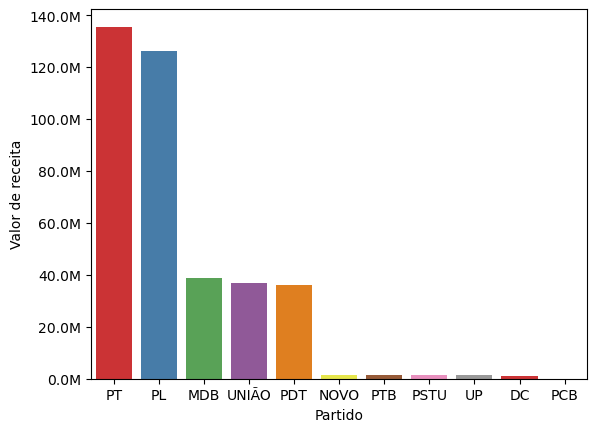

In [191]:
sns.barplot(data = df_receita_por_candidato , x= 'Partido', y= 'Valor de receita',hue= 'Partido', palette='Set1', legend=False)
ax = plt.gca()

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f'{y/1e6:.1f}M'))
plt.show()

In [197]:

seg_turno_df = candidaturas_df[candidaturas_df['Situação de totalização'] == '2º turno']
tabela_receitas_seg_turno = seg_turno_df.pivot_table(index= 'Nome candidato', columns= 'Fonte de receita', values= 'Valor de receita', aggfunc= 'sum')
tabela_receitas_seg_turno

Fonte de receita,FUNDO ESPECIAL,FUNDO PARTIDARIO,OUTROS RECURSOS
Nome candidato,,,
JAIR MESSIAS BOLSONARO,"R$ 1,988,972.68","R$ 29,447,388.77","R$ 94,691,156.01"
LUIZ INÁCIO LULA DA SILVA,"R$ 125,119,008.86","R$ 242,092.25","R$ 10,178,186.71"


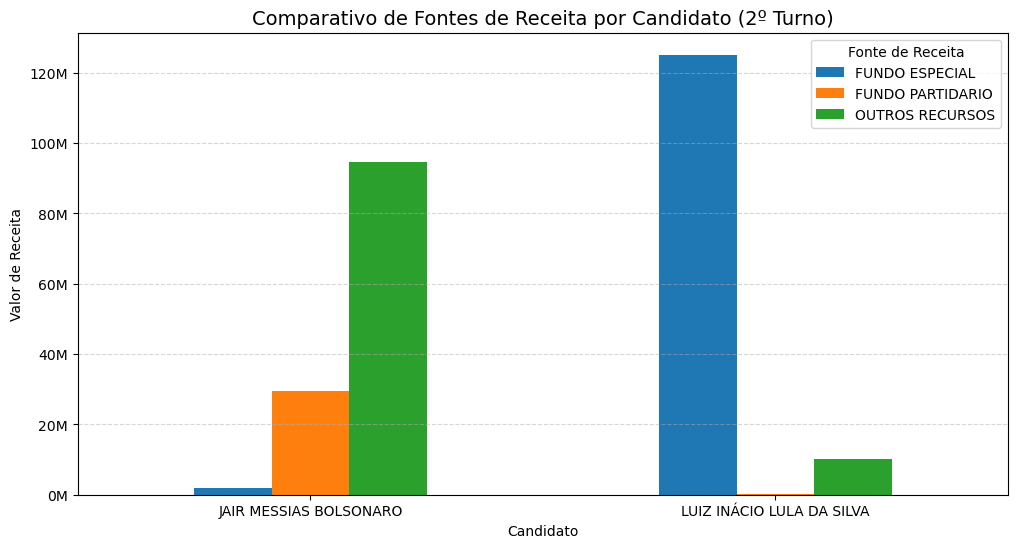

In [201]:
df_plot = tabela_receitas_seg_turno

# 2. Plota com kind='bar' (sem o stacked=True)
ax = df_plot.plot(kind='bar', figsize=(12, 6))

# 3. Formatações visuais
plt.title('Comparativo de Fontes de Receita por Candidato (2º Turno)', fontsize=14)
plt.ylabel('Valor de Receita')
plt.xlabel('Candidato')
plt.xticks(rotation=0) # Mantém os nomes dos candidatos na horizontal
plt.legend(title='Fonte de Receita', loc='upper right')

# Formata o eixo Y para aparecer em milhões
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f'{y/1e6:.0f}M'))

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.savefig('comparativo_fontes_receita_agrupado.png', dpi=300, bbox_inches='tight')
plt.show()

# print(tabela_receitas_seg_turno.dtypes)

In [114]:
try:
    votos_df = pd.read_csv('votacao_candidato.csv', sep=';', encoding='iso-8859-1')
    print('CSV lido com sucesso!')
except FileNotFoundError:
    print('Arquivo não encontrado!')

CSV lido com sucesso!


In [154]:
# votos_df.sample(10)

In [126]:
votos_por_cand_df = votos_df.groupby('Nome candidato')['Votos nominais'].sum().reset_index().sort_values(by= 'Votos nominais', ascending= False)
votos_por_cand_df

,Nome candidato,Votos nominais
6,LUIZ INÁCIO LULA DA SILVA,57259504
1,JAIR MESSIAS BOLSONARO,51072345
7,SIMONE NASSAR TEBET,4915423
0,CIRO FERREIRA GOMES,3599287
9,SORAYA VIEIRA THRONICKE,600955
5,LUIZ FELIPE CHAVES D'AVILA,559708
3,KELMON LUIS DA SILVA SOUZA,81129
4,LEONARDO PÉRICLES VIEIRA ROQUE,53519
8,SOFIA PADUA MANZANO,45620
10,VERA LUCIA PEREIRA DA SILVA SALGADO,25625


In [127]:
candidato_total_df = pd.merge(df_receita_por_candidato, votos_por_cand_df, on= 'Nome candidato')

candidato_total_df

,Nome candidato,Partido,Situação de totalização,Valor de receita,Votos nominais
0,LUIZ INÁCIO LULA DA SILVA,PT,2º turno,"R$ 135,539,287.82",57259504
1,JAIR MESSIAS BOLSONARO,PL,2º turno,"R$ 126,127,517.46",51072345
2,SIMONE NASSAR TEBET,MDB,Não eleito,"R$ 38,828,942.91",4915423
3,SORAYA VIEIRA THRONICKE,UNIÃO,Não eleito,"R$ 36,675,548.85",600955
4,CIRO FERREIRA GOMES,PDT,Não eleito,"R$ 36,013,770.24",3599287
5,KELMON LUIS DA SILVA SOUZA,PTB,Não eleito,"R$ 1,545,000.00",81129
6,VERA LUCIA PEREIRA DA SILVA SALGADO,PSTU,Não eleito,"R$ 1,359,238.35",25625
7,LEONARDO PÉRICLES VIEIRA ROQUE,UP,Não eleito,"R$ 1,307,411.22",53519
8,JOSE MARIA EYMAEL,DC,Não eleito,"R$ 1,176,433.50",16604
9,SOFIA PADUA MANZANO,PCB,Não eleito,"R$ 25,940.50",45620


In [128]:
candidato_total_df['Custo por voto'] = candidato_total_df['Valor de receita'] / candidato_total_df['Votos nominais'] 

In [129]:
candidato_total_df

,Nome candidato,Partido,Situação de totalização,Valor de receita,Votos nominais,Custo por voto
0,LUIZ INÁCIO LULA DA SILVA,PT,2º turno,"R$ 135,539,287.82",57259504,R$ 2.37
1,JAIR MESSIAS BOLSONARO,PL,2º turno,"R$ 126,127,517.46",51072345,R$ 2.47
2,SIMONE NASSAR TEBET,MDB,Não eleito,"R$ 38,828,942.91",4915423,R$ 7.90
3,SORAYA VIEIRA THRONICKE,UNIÃO,Não eleito,"R$ 36,675,548.85",600955,R$ 61.03
4,CIRO FERREIRA GOMES,PDT,Não eleito,"R$ 36,013,770.24",3599287,R$ 10.01
5,KELMON LUIS DA SILVA SOUZA,PTB,Não eleito,"R$ 1,545,000.00",81129,R$ 19.04
6,VERA LUCIA PEREIRA DA SILVA SALGADO,PSTU,Não eleito,"R$ 1,359,238.35",25625,R$ 53.04
7,LEONARDO PÉRICLES VIEIRA ROQUE,UP,Não eleito,"R$ 1,307,411.22",53519,R$ 24.43
8,JOSE MARIA EYMAEL,DC,Não eleito,"R$ 1,176,433.50",16604,R$ 70.85
9,SOFIA PADUA MANZANO,PCB,Não eleito,"R$ 25,940.50",45620,R$ 0.57


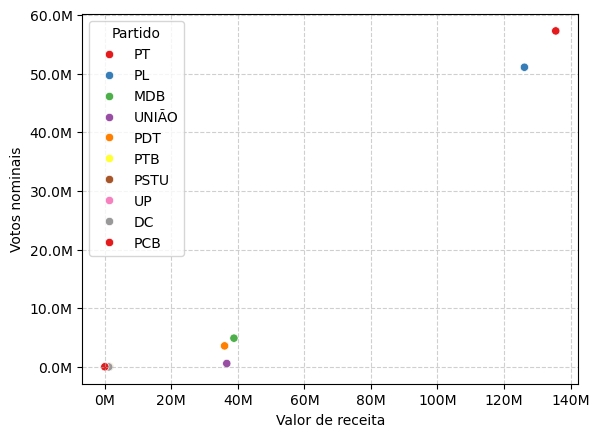

In [208]:
sns.scatterplot(data= candidato_total_df, x= 'Valor de receita', y= 'Votos nominais', hue= 'Partido', palette='Set1', legend=True)

ax = plt.gca()

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M'))

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f'{y/1e6:.1f}M'))
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('grafico_dispersao_eleicoes.png', dpi=300, bbox_inches='tight')
plt.show()

In [209]:
# .median() 
# candidato_total_df['Média custo por voto'] = candidato_total_df['Custo por voto'].mean()
# candidato_total_df['Mediana custo por voto'] = candidato_total_df['Custo por voto'].median()

In [210]:
candidato_total_df

,Nome candidato,Partido,Situação de totalização,Valor de receita,Votos nominais,Custo por voto,Média custo por voto,Mediana custo por voto
0,LUIZ INÁCIO LULA DA SILVA,PT,2º turno,"R$ 135,539,287.82",57259504,R$ 2.37,R$ 25.17,R$ 14.52
1,JAIR MESSIAS BOLSONARO,PL,2º turno,"R$ 126,127,517.46",51072345,R$ 2.47,R$ 25.17,R$ 14.52
2,SIMONE NASSAR TEBET,MDB,Não eleito,"R$ 38,828,942.91",4915423,R$ 7.90,R$ 25.17,R$ 14.52
3,SORAYA VIEIRA THRONICKE,UNIÃO,Não eleito,"R$ 36,675,548.85",600955,R$ 61.03,R$ 25.17,R$ 14.52
4,CIRO FERREIRA GOMES,PDT,Não eleito,"R$ 36,013,770.24",3599287,R$ 10.01,R$ 25.17,R$ 14.52
5,KELMON LUIS DA SILVA SOUZA,PTB,Não eleito,"R$ 1,545,000.00",81129,R$ 19.04,R$ 25.17,R$ 14.52
6,VERA LUCIA PEREIRA DA SILVA SALGADO,PSTU,Não eleito,"R$ 1,359,238.35",25625,R$ 53.04,R$ 25.17,R$ 14.52
7,LEONARDO PÉRICLES VIEIRA ROQUE,UP,Não eleito,"R$ 1,307,411.22",53519,R$ 24.43,R$ 25.17,R$ 14.52
8,JOSE MARIA EYMAEL,DC,Não eleito,"R$ 1,176,433.50",16604,R$ 70.85,R$ 25.17,R$ 14.52
9,SOFIA PADUA MANZANO,PCB,Não eleito,"R$ 25,940.50",45620,R$ 0.57,R$ 25.17,R$ 14.52


In [211]:
PT_PL_df= seg_turno_df.groupby('Nome candidato')['Valor de receita'].sum().reset_index()
PT_PL_df

,Nome candidato,Valor de receita
0,JAIR MESSIAS BOLSONARO,"R$ 126,127,517.46"
1,LUIZ INÁCIO LULA DA SILVA,"R$ 135,539,287.82"


In [153]:
porcentagem_receita_PT_PL = float(PT_PL_df['Valor de receita'].sum() / candidato_total_df['Valor de receita'].sum() * 100)
print(f'A porcentagem de receitas de Jair Bolsonaro e Lula são aproximadamente {porcentagem_receita_PT_PL:.3f}% do total de receitas')

A porcentagem de receitas de Jair Bolsonaro e Lula são aproximadamente 69.114% do total de receitas


In [205]:
candidato_total_df.head()

,Nome candidato,Partido,Situação de totalização,Valor de receita,Votos nominais,Custo por voto,Média custo por voto,Mediana custo por voto
0,LUIZ INÁCIO LULA DA SILVA,PT,2º turno,"R$ 135,539,287.82",57259504,R$ 2.37,R$ 25.17,R$ 14.52
1,JAIR MESSIAS BOLSONARO,PL,2º turno,"R$ 126,127,517.46",51072345,R$ 2.47,R$ 25.17,R$ 14.52
2,SIMONE NASSAR TEBET,MDB,Não eleito,"R$ 38,828,942.91",4915423,R$ 7.90,R$ 25.17,R$ 14.52
3,SORAYA VIEIRA THRONICKE,UNIÃO,Não eleito,"R$ 36,675,548.85",600955,R$ 61.03,R$ 25.17,R$ 14.52
4,CIRO FERREIRA GOMES,PDT,Não eleito,"R$ 36,013,770.24",3599287,R$ 10.01,R$ 25.17,R$ 14.52
